# Beat Tracker and Tempo Estimation
- Asa Picton, Connor Richardson, Dylan Baecker
- CSC475

### 1. Import libraries

In [21]:

from pathlib import Path
from joblib import Parallel, delayed
import joblib
import numpy as np
import pandas as pd
import librosa as lb
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestRegressor



### 2. Load audio and tempo data

In [22]:
audio_path = Path("giantsteps-tempo-dataset/audio")
label_path = Path("giantsteps-tempo-dataset/annotations/tempo")

# Load tempo labels
tempo_labels = {}
for file in label_path.iterdir():
    tempo_labels[file.stem] = float(file.read_text().strip())

# Build dataset
dataset = []
for file in audio_path.iterdir():
    track_id = file.stem
    if track_id in tempo_labels:
        dataset.append((file, tempo_labels[track_id]))

print(f"Loaded {len(dataset)} audio tracks with tempo labels")


Loaded 664 audio tracks with tempo labels


In [23]:
print(len(dataset))
print(dataset[0])
print(dataset[0][0].exists())

664
(PosixPath('giantsteps-tempo-dataset/audio/3226172.LOFI.mp3'), 69.0)
True


### 3. Feature Extraction

In [24]:
def root_mean_square(y_audio, sr):
    rms_vals = lb.feature.rms(y=y_audio)[0]
    rms_features = np.array([
        np.mean(rms_vals),
        np.std(rms_vals),
        np.max(rms_vals),
        np.min(rms_vals)
    ])
    return rms_features

def onset_envelope(y_audio, sr):
    onset_env = lb.onset.onset_strength(y=y_audio, sr=sr)
    onset_features = np.array([
        np.mean(onset_env),
        np.std(onset_env),
        np.max(onset_env),
            np.min(onset_env)
    ])
    return onset_features

def tempogram_features(y_audio, sr):
    onset_env = lb.onset.onset_strength(y=y_audio, sr=sr)
    tg = lb.feature.tempogram(onset_envelope=onset_env, sr=sr)
    tg_mean = np.mean(tg, axis=1)
    tg_mean = np.clip(tg_mean, 0, 1e6)  # guard against inf/extreme values
    tempo_freqs = lb.tempo_frequencies(len(tg_mean), sr=sr)
    peak_bpm = tempo_freqs[np.argmax(tg_mean)]
    
    return np.array([
        peak_bpm,
        np.mean(tg_mean),
        np.std(tg_mean),
        np.max(tg_mean)
    ])


def process_track(path, bpm):
    #Only use 30s clips of each track
    y_audio, sr = lb.load(path, duration=30)
    features = np.concatenate([
        root_mean_square(y_audio, sr),
        onset_envelope(y_audio, sr),
        tempogram_features(y_audio, sr)
    ])
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    return features, bpm


In [25]:
CACHE_FILE = Path("features_cache.pkl")

if CACHE_FILE.exists():
    # Skips recomputation on subsequent runs
    print("Loading features from cache")
    X, y = joblib.load(CACHE_FILE)
    print(f"Loaded {len(X)} cached feature vectors.")
else:
    print("Extracting features")

    results = Parallel(n_jobs=-1)(
        delayed(process_track)(path, bpm)
        for path, bpm in tqdm(dataset, desc="Tracks")
    )
    X, y = zip(*results)

    joblib.dump((X, y), CACHE_FILE)
    print(f"Extracted features for {len(X)} tracks. Saved to {CACHE_FILE}.")

Extracting features


Tracks: 100%|██████████| 664/664 [00:47<00:00, 13.85it/s]


Extracted features for 664 tracks. Saved to features_cache.pkl.


60-90       70
90-110      27
110-130    168
130-150    229
150-200    168
Name: count, dtype: int64


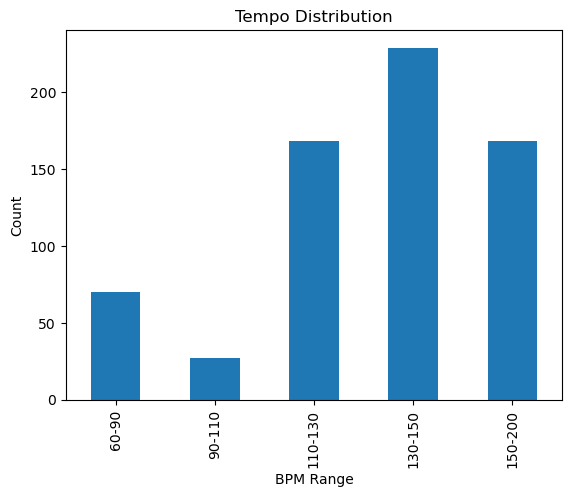

In [26]:
tempo_bins = pd.cut(y, bins=[60, 90, 110, 130, 150, 200], labels=["60-90", "90-110", "110-130", "130-150", "150-200"])

print(tempo_bins.value_counts().sort_index())
tempo_bins.value_counts().sort_index().plot(kind="bar")
plt.xlabel("BPM Range")
plt.ylabel("Count")
plt.title("Tempo Distribution")
plt.show()

2 smallest bins (60/90) are extremely low, will merge the 60-110

0-110       99
110-130    168
130-150    229
150-200    168
Name: count, dtype: int64


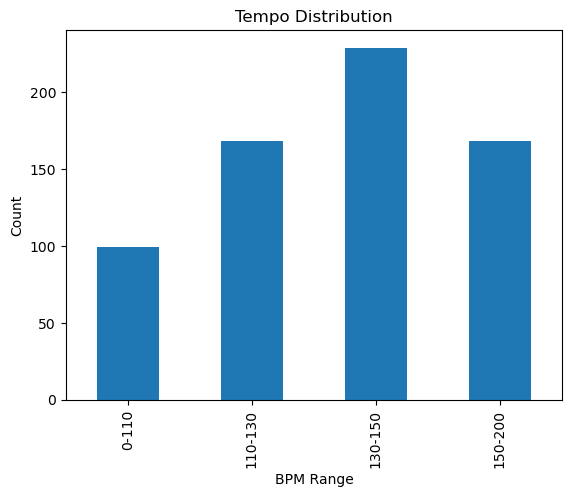

In [27]:
tempo_bins = pd.cut(y, bins=[0, 110, 130, 150, 200], labels=["0-110", "110-130", "130-150", "150-200"])

print(tempo_bins.value_counts().sort_index())
tempo_bins.value_counts().sort_index().plot(kind="bar")
plt.xlabel("BPM Range")
plt.ylabel("Count")
plt.title("Tempo Distribution")
plt.show()

In [28]:
tempo_bins = pd.cut(y, bins=[0, 110, 130, 150, 200]).astype(str)

### 4. Model Training (RFRegressor)

In [29]:
def evaluate(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Accuracy 1
    acc1 = np.mean(np.abs(y_pred - y_true) / y_true < 0.04)

    # Balanced accuracy
    bins = [0, 110, 130, 150, 200]
    true_bins = pd.cut(y_true, bins=bins).astype(str)
    pred_bins = pd.cut(y_pred, bins=bins).astype(str)
    bal_acc = balanced_accuracy_score(true_bins, pred_bins)

    print(f"Accuracy 1:          {acc1:.3f}")
    print(f"Balanced Accuracy:   {bal_acc:.3f}")

In [30]:
X = np.array(X)
y = np.array(y)

def training_loop(X, y, tempo_bins):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, tempo_bins)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = RandomForestRegressor()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        print(f"\nFold {fold + 1}")
        evaluate(y_test, y_pred)

training_loop(X, y, tempo_bins)


Fold 1
Accuracy 1:          0.226
Balanced Accuracy:   0.329

Fold 2
Accuracy 1:          0.180
Balanced Accuracy:   0.317

Fold 3
Accuracy 1:          0.218
Balanced Accuracy:   0.298

Fold 4
Accuracy 1:          0.233
Balanced Accuracy:   0.327

Fold 5
Accuracy 1:          0.189
Balanced Accuracy:   0.272
